In [15]:
# SPRINT 1: Air Quality Prediction MVP
# Target: NO2 (Nitrogen Dioxide)
# Horizon: 24h prediction
# Metrics: Mean Squared Error (MSE) and R2 Score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import glob
import os

# US #17: Requirements definition
TARGET = 'PM2.5'
STATIONS = ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 
            'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wushanyi']

print(f"Project initialized. Target: {TARGET} across {len(STATIONS)} stations.")

Project initialized. Target: PM2.5 across 12 stations.


In [16]:
# US #18: Raw data ingestion and consolidation
# We assume the CSV files are named after the stations or are in the same folder

def ingest_beijing_data(folder_path="."):
    all_files = glob.glob(os.path.join(folder_path, "PRSA_Data_*.csv"))
    
    if not all_files:
        print("No CSV files found! Make sure the Beijing dataset is in the folder.")
        return pd.DataFrame()

    df_list = []
    for filename in all_files:
        df_temp = pd.read_csv(filename)
        df_list.append(df_temp)
    
    # Consolidate all 12 stations
    full_df = pd.concat(df_list, ignore_index=True)
    print(f"Successfully ingested {len(all_files)} files.")
    print(f"Total instances: {full_df.shape[0]}")
    return full_df

raw_df = ingest_beijing_data()
raw_df.head()

Successfully ingested 12 files.
Total instances: 420768


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


--- Missing Values Report ---
PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
wd        1822
WSPM       318
dtype: int64

--- Feature Statistics (Beijing Air Quality) ---
               PM2.5           PM10            SO2            NO2  \
count  412029.000000  414319.000000  411747.000000  408652.000000   
mean       79.793428     104.602618      15.830835      50.638586   
std        80.822391      91.772426      21.650603      35.127912   
min         2.000000       2.000000       0.285600       1.026500   
25%        20.000000      36.000000       3.000000      23.000000   
50%        55.000000      82.000000       7.000000      43.000000   
75%       111.000000     145.000000      20.000000      71.000000   
max       999.000000     999.000000     500.000000     290.000000   

                  CO             O3           TEMP           PRES  \
count  400067.000000  407491.000000 

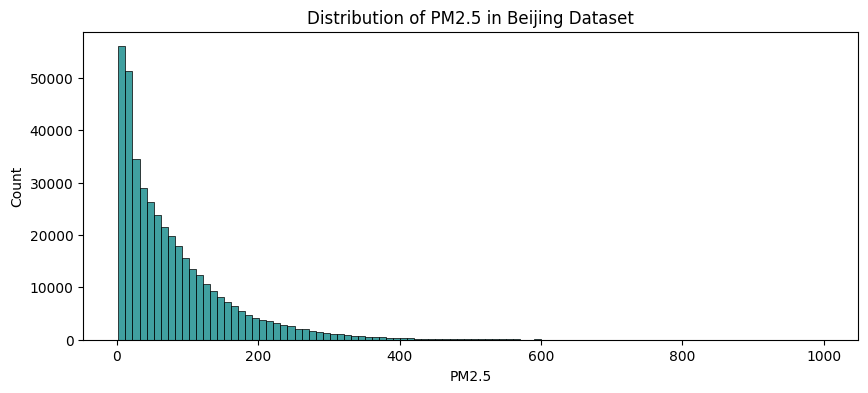

In [17]:
# US #20: Data profiling and quality checks

print("--- Missing Values Report ---")
missing = raw_df.isnull().sum()
print(missing[missing > 0])

print("\n--- Feature Statistics (Beijing Air Quality) ---")
# Mostramos estadísticas de contaminantes clave y meteorología
cols_of_interest = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'WSPM']
print(raw_df[cols_of_interest].describe())

# Check target distribution
plt.figure(figsize=(10, 4))
sns.histplot(raw_df[TARGET].dropna(), bins=100, color='teal')
plt.title(f"Distribution of {TARGET} in Beijing Dataset")
plt.show()

In [18]:
# US #21: Timestamp construction and categorical encoding

def preprocess_beijing_time(df):
    df_p = df.copy()
    
    # 1. Create timestamp from year, month, day, hour
    df_p['timestamp'] = pd.to_datetime(df_p[['year', 'month', 'day', 'hour']])
    
    # 2. Set index and sort
    df_p = df_p.set_index('timestamp').sort_index()
    
    # 3. Encoding categorical: Wind Direction (wd) and Station
    # Using LabelEncoder for simplicity in this baseline
    le_wd = LabelEncoder()
    df_p['wd'] = le_wd.fit_transform(df_p['wd'].astype(str))
    
    le_station = LabelEncoder()
    df_p['station_code'] = le_station.fit_transform(df_p['station'])
    
    print("Timestamps aligned and categorical variables encoded.")
    return df_p

processed_df = preprocess_beijing_time(raw_df)
processed_df[['PM2.5', 'station', 'station_code', 'wd']].head()

Timestamps aligned and categorical variables encoded.


,PM2.5,station,station_code,wd
timestamp,,,,
2013-03-01,4.0,Aotizhongxin,0,6
2013-03-01,6.0,Tiantan,9,6
2013-03-01,4.0,Dingling,2,0
2013-03-01,8.0,Wanliu,10,6
2013-03-01,3.0,Changping,1,0


In [19]:
# US #22 & #23: Imputation and Scaling

# US #22: Missing value imputation (Linear interpolation per station)
# We group by station to avoid bleeding data from one location to another
processed_df[TARGET] = processed_df.groupby('station')[TARGET].transform(lambda x: x.interpolate(method='linear'))
# Drop remaining NaNs that couldn't be interpolated (e.g., at the very start)
processed_df.dropna(subset=[TARGET], inplace=True)

# US #23: Scaling numeric parameters
scaler = StandardScaler()
# Features to scale: pollutants + meteorology
numeric_cols = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
processed_df[numeric_cols] = scaler.fit_transform(processed_df[numeric_cols])

print("Data cleaning and scaling completed.")
processed_df.head()

Data cleaning and scaling completed.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,station_code
timestamp,,,,,,,,,,,,,,,,,,,
2013-03-01,1,2013,3,1,0,4.0,-1.096220,-0.546444,-1.242278,-0.802260,0.346403,-1.245087,1.169846,-1.543503,-0.078533,6,2.142429,Aotizhongxin,0
2013-03-01,1,2013,3,1,0,6.0,-1.074427,-0.546444,-1.213811,-0.802260,0.416998,-1.227599,1.313057,-1.731993,-0.078533,6,3.185446,Tiantan,9
2013-03-01,1,2013,3,1,0,4.0,-1.096220,-0.592632,NaN,-0.888453,0.434646,-1.384995,0.959803,-1.608750,-0.078533,0,-0.986622,Dingling,2
2013-03-01,1,2013,3,1,0,8.0,-1.052634,-0.454068,-0.644462,-0.716066,-0.094813,-1.245087,1.169846,-1.543503,-0.078533,6,2.142429,Wanliu,10
2013-03-01,1,2013,3,1,0,3.0,-1.074427,-0.130751,-1.242278,-0.802260,0.487592,-1.384995,0.959803,-1.608750,-0.078533,0,-0.986622,Changping,1


In [20]:
# US #24: Time windows and leakage-safe chronological splits (Multivariate)

FEATURE_COLS = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'TEMP', 'PRES', 'WSPM', 'wd']
LOOKBACK = 24
HORIZONS = [1, 12, 24]

def create_multivariate_windows(df, feature_cols, target_col, lookback=24, horizon=1):
    X, y = [], []
    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        
        feature_data = station_df[feature_cols].values
        target_data = station_df[target_col].values
        
        for i in range(lookback, len(station_df) - horizon + 1):
            X.append(feature_data[i-lookback:i, :].flatten())
            y.append(target_data[i + horizon - 1])
            
    return np.array(X), np.array(y)

split_idx = int(len(processed_df) * 0.8)
train_df = processed_df.iloc[:split_idx]
test_df = processed_df.iloc[split_idx:]

print(f"Data ready. We will train models for horizons: {HORIZONS} hours.")

Data ready. We will train models for horizons: [1, 12, 24] hours.


In [21]:
# US #26: Train Random Forest baselines for multiple horizons
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

models_dict = {}
predictions_dict = {}
metrics_dict = {}
feature_importances_dict = {}

print("Starting Fast Training Loop (Baseline MVP)...")

for h in HORIZONS:
    print(f"\n--- Training Model for Horizon: +{h}h ---")
    
    X_train_h, y_train_h = create_multivariate_windows(train_df, FEATURE_COLS, TARGET, lookback=LOOKBACK, horizon=h)
    X_test_h, y_test_h = create_multivariate_windows(test_df, FEATURE_COLS, TARGET, lookback=LOOKBACK, horizon=h)
    
    # Truco MVP: Usamos solo 50.000 muestras para que no tarde horas
    X_train_sample = X_train_h[-50000:]
    y_train_sample = y_train_h[-50000:]
    
    rf = RandomForestRegressor(n_estimators=20, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X_train_sample, y_train_sample)
    
    test_pred_h = rf.predict(X_test_h)
    
    mae = mean_absolute_error(y_test_h, test_pred_h)
    rmse = np.sqrt(mean_squared_error(y_test_h, test_pred_h))
    r2 = r2_score(y_test_h, test_pred_h)
    
    print(f"Done! R2 Score: {r2*100:.2f}% | RMSE: {rmse:.2f}")
    
    models_dict[h] = rf
    predictions_dict[h] = {'y_true': y_test_h, 'y_pred': test_pred_h}
    metrics_dict[h] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    feature_importances_dict[h] = rf.feature_importances_

print("\nAll models trained successfully!")

Starting Fast Training Loop (Baseline MVP)...

--- Training Model for Horizon: +1h ---
Done! R2 Score: 94.70% | RMSE: 19.17

--- Training Model for Horizon: +12h ---
Done! R2 Score: 38.73% | RMSE: 65.22

--- Training Model for Horizon: +24h ---
Done! R2 Score: 26.43% | RMSE: 71.51

All models trained successfully!


     HORIZON PERFORMANCE COMPARISON     
Horizon    | R2 Score (%) | RMSE (µg/m³)   
----------------------------------------
+1h        |       94.70% |         19.17
+12h        |       38.73% |         65.22
+24h        |       26.43% |         71.51



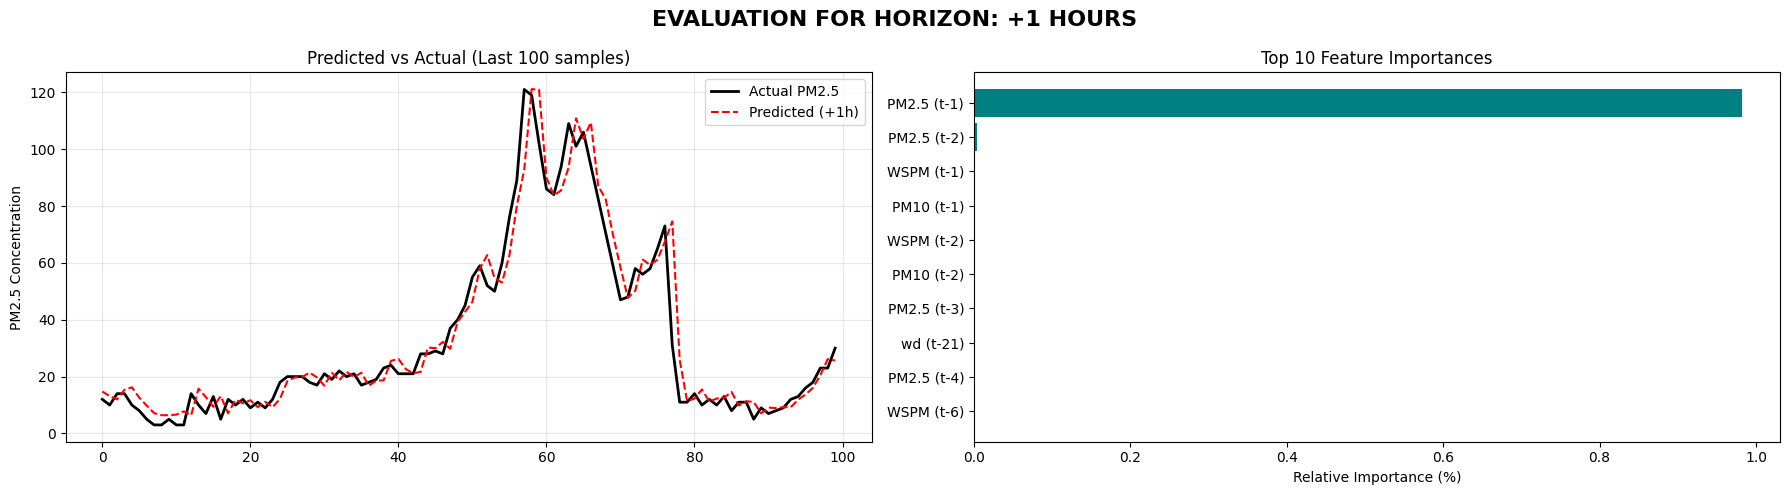

Top 5 Drivers for +1h forecast:
  - PM2.5 (t-1)    : 98.16%
  - PM2.5 (t-2)    : 0.39%
  - WSPM (t-1)     : 0.10%
  - PM10 (t-1)     : 0.10%
  - WSPM (t-2)     : 0.04%
--------------------------------------------------------------------------------


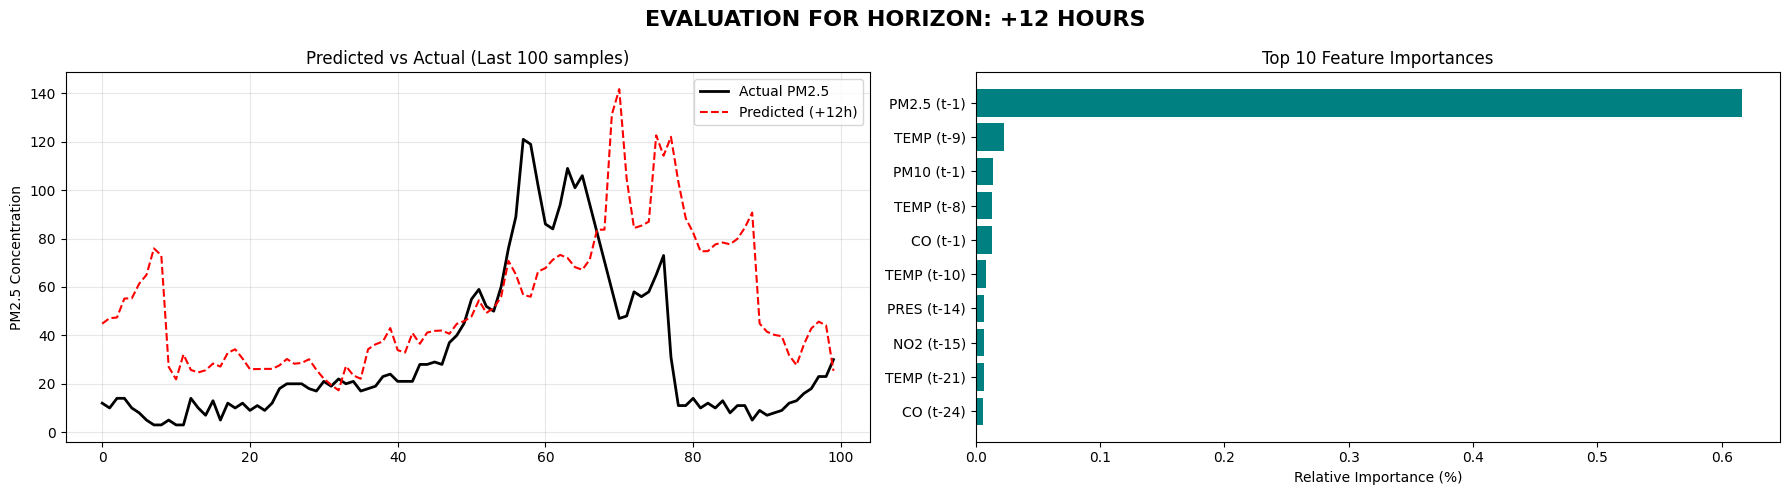

Top 5 Drivers for +12h forecast:
  - PM2.5 (t-1)    : 61.60%
  - TEMP (t-9)     : 2.30%
  - PM10 (t-1)     : 1.42%
  - TEMP (t-8)     : 1.31%
  - CO (t-1)       : 1.28%
--------------------------------------------------------------------------------


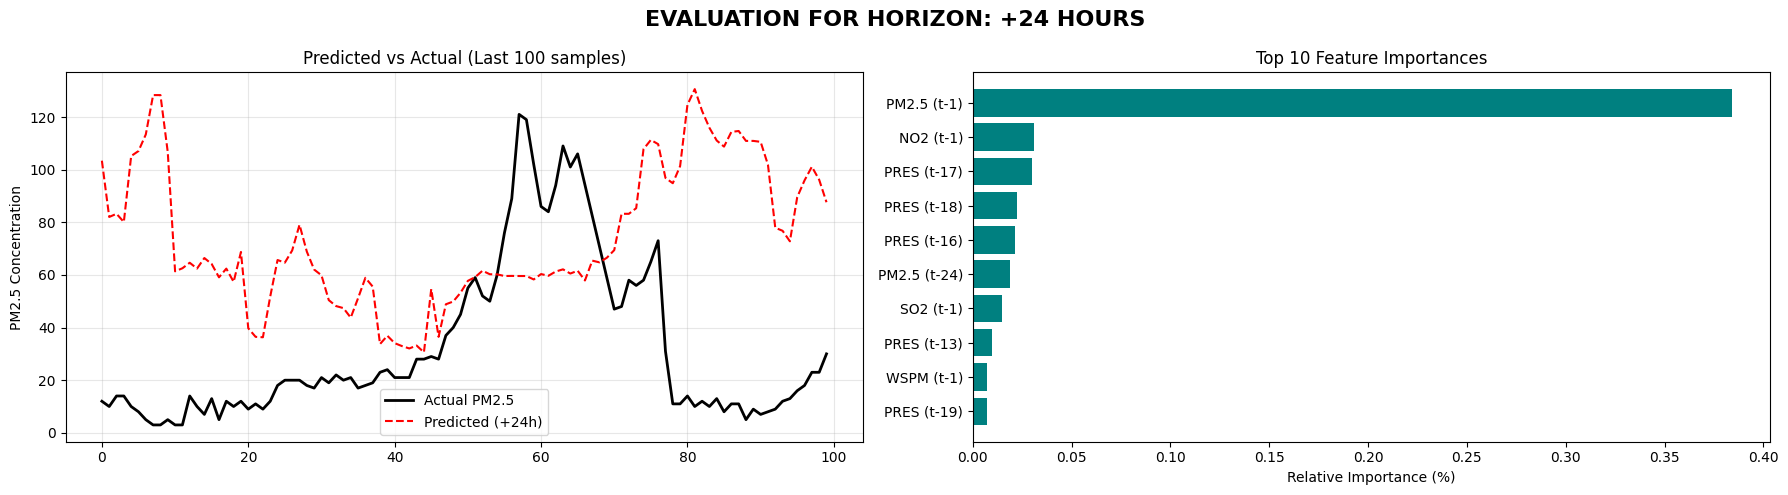

Top 5 Drivers for +24h forecast:
  - PM2.5 (t-1)    : 38.41%
  - NO2 (t-1)      : 3.09%
  - PRES (t-17)    : 2.98%
  - PRES (t-18)    : 2.24%
  - PRES (t-16)    : 2.11%
--------------------------------------------------------------------------------


In [24]:
# US #28: Comprehensive Evaluation Report (Multivariate Features)
import matplotlib.pyplot as plt
import numpy as np

# 1. Imprimir Tabla Comparativa de Métricas
print("========================================")
print("     HORIZON PERFORMANCE COMPARISON     ")
print("========================================")
print(f"{'Horizon':<10} | {'R2 Score (%)':<12} | {'RMSE (µg/m³)':<15}")
print("-" * 40)
for h in HORIZONS:
    m = metrics_dict[h]
    print(f"+{h}h{' ':<7} | {m['R2']*100:>11.2f}% | {m['RMSE']:>13.2f}")
print("========================================\n")

# 2. Generar nombres de features aplanadas para la gráfica de importancia
feature_names = []
for i in range(LOOKBACK, 0, -1):
    for col in FEATURE_COLS:
        feature_names.append(f"{col} (t-{i})")

# 3. Dibujar gráficos para cada horizonte
for h in HORIZONS:
    y_true = predictions_dict[h]['y_true']
    y_pred = predictions_dict[h]['y_pred']
    importances = feature_importances_dict[h]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f"EVALUATION FOR HORIZON: +{h} HOURS", fontsize=16, fontweight='bold')
    
    # Gráfico A: Predicho vs Real (Últimas 100 horas) -> axes[0]  ✅
    axes[0].plot(y_true[-100:], label="Actual PM2.5", color='black', linewidth=2)
    axes[0].plot(y_pred[-100:], label=f"Predicted (+{h}h)", color='red', linestyle='--')
    axes[0].set_title(f"Predicted vs Actual (Last 100 samples)")
    axes[0].set_ylabel("PM2.5 Concentration")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Gráfico B: Top 10 Feature Importances -> axes[1]  ✅
    indices = np.argsort(importances)[-10:]
    axes[1].barh(range(len(indices)), importances[indices], color='teal', align='center')
    axes[1].set_yticks(range(len(indices)))
    axes[1].set_yticklabels([feature_names[i] for i in indices])
    axes[1].set_title(f"Top 10 Feature Importances")
    axes[1].set_xlabel('Relative Importance (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir los números exactos del Top 5 de importancia
    print(f"Top 5 Drivers for +{h}h forecast:")
    for i in reversed(indices[-5:]):
        print(f"  - {feature_names[i]:<15}: {importances[i]*100:.2f}%")
    print("-" * 80)

In [ ]:
# US #30: Select final model and export inference bundle

# Guardamos el modelo entrenado y el objeto scaler
joblib.dump(rf_model, 'beijing_rf_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print("Inference bundle exported: 'beijing_rf_model.pkl' and 'feature_scaler.pkl'")
print("--- END OF SPRINT 1 ---")

Inference bundle exported: 'beijing_rf_model.pkl' and 'feature_scaler.pkl'
--- END OF SPRINT 1 ---
